# A harder test: 3×3 lattice Bayes net with colliders

Nine continuous variables on `[0,100]` on a grid, thresholded at 50. Edges go
right and down, so every interior node has **two parents** — it is a **collider**:

```
(0,0) → (0,1) → (0,2)
  ↓       ↓       ↓
(1,0) → (1,1) → (1,2)
  ↓       ↓       ↓
(2,0) → (2,1) → (2,2)
```

Colliders `(1,1),(1,2),(2,1),(2,2)` get **AND / OR** gates — non-additive CPDs, so
each is a genuine 3-way interaction that pairwise constraints cannot express. We
fit the **linear tensor chain** (row-major ordering of the grid) on constraints
only, and compare against the exact `2⁹`-state binary net.

The question this tests: **what constraints reproduce a collider?**

In [ ]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
from calibrated_response.tn import plot_pairwise
from examples.maxent_tests.tn_lattice_demo import (
    NODES, IDX, analytic_joint, analytic_marginals,
    make_model, fit, report,
    lattice_constraints_cpd, lattice_constraints_family,
)

J = analytic_joint()
print("analytic P(node>50):")
for node in NODES:
    print(f"  {node} = {analytic_marginals(J)[IDX[node]]:.3f}")

analytic P(node>50):
  (0, 0) = 0.600
  (0, 1) = 0.570
  (0, 2) = 0.549
  (1, 0) = 0.570
  (1, 1) = 0.482
  (1, 2) = 0.600
  (2, 0) = 0.549
  (2, 1) = 0.600
  (2, 2) = 0.463


## Attempt 1 — collider **CPD conditionals** (triplet *conditionals*)

Specify each node's CPD: root prior, single-parent `P(child|parent)`, and for
each collider the four triplet conditionals `P(child>50 | p1 vs 50, p2 vs 50)`
(these use `cond_prob` with a two-site `given` — a real collider CPD).

In [ ]:
m1 = make_model(bins=8, bond_dim=16, kind="born")
c1 = lattice_constraints_cpd(m1)
p1, h1 = fit(m1, c1)
print(f"final loss = {h1[-1]:.2e}")
e1 = report(m1, p1, c1, "collider CPD conditionals")

final loss = 1.79e-09

=== collider CPD conditionals ===
  constraint residual: max 0.0000  mean 0.0000  (25 constraints)
  propagated P(node>50): node  model  analytic  err
    (0, 0)   0.600   0.600   0.000
    (0, 1)   0.570   0.570   0.000
    (0, 2)   0.549   0.549   0.000
    (1, 0)   0.570   0.570   0.000
    (1, 1)   0.527   0.482   0.045
    (1, 2)   0.547   0.600   0.052
    (2, 0)   0.549   0.549   0.000
    (2, 1)   0.544   0.600   0.056
    (2, 2)   0.521   0.463   0.057
  max |model-analytic| over nodes = 0.057


The constraints are satisfied **exactly**, and every single-parent node matches
the analytic net — but the **colliders drift ~0.05**. Why? A conditional
`P(child|p1,p2)` pins the CPD but says nothing about the **joint of the parents**
`P(p1,p2)`. The propagated collider marginal is
`P(child>50) = Σ P(child>50|p1,p2)·P(p1,p2)`, and the constraint set leaves
`P(p1,p2)` free (the Bayes net's conditional-independence structure is not implied
by the CPDs). So the collider marginals are under-determined.

## Attempt 2 — collider **triplet marginals**

Fix it the way the structure demands: constrain each node's **family marginal** —
the joint threshold table over `{node} ∪ parents` (root → 1-site, single-parent →
pair, **collider → triplet** `P(child,p1,p2)`). The triplet *marginal* pins both
the CPD and the parents' joint at once.

In [ ]:
m2 = make_model(bins=8, bond_dim=16, kind="born")
c2 = lattice_constraints_family(m2, J)
p2, h2 = fit(m2, c2)
print(f"final loss = {h2[-1]:.2e}")
e2 = report(m2, p2, c2, "collider triplet marginals")
print(f"\nmax node error:  CPD-conditionals {e1:.3f}   triplet-marginals {e2:.3f}")

final loss = 2.40e-07

=== collider triplet marginals ===
  constraint residual: max 0.0002  mean 0.0000  (50 constraints)
  propagated P(node>50): node  model  analytic  err
    (0, 0)   0.600   0.600   0.000
    (0, 1)   0.570   0.570   0.000
    (0, 2)   0.549   0.549   0.000
    (1, 0)   0.570   0.570   0.000
    (1, 1)   0.482   0.482   0.000
    (1, 2)   0.600   0.600   0.000
    (2, 0)   0.549   0.549   0.000
    (2, 1)   0.600   0.600   0.000
    (2, 2)   0.463   0.463   0.000
  max |model-analytic| over nodes = 0.000

max node error:  CPD-conditionals 0.057   triplet-marginals 0.000


Now **every node matches the analytic net to 0.000** — the tensor chain reproduces
the full 3×3 lattice, colliders included. The takeaway: *triplet constraints* are
necessary for colliders, but it must be the triplet **marginal** `P(child,p1,p2)`,
not the CPD **conditional** `P(child|p1,p2)`. The marginal carries the parents'
joint (the collider's incoming correlation); the conditional does not.

### Pairwise marginals of the reproduced lattice (exact contractions)

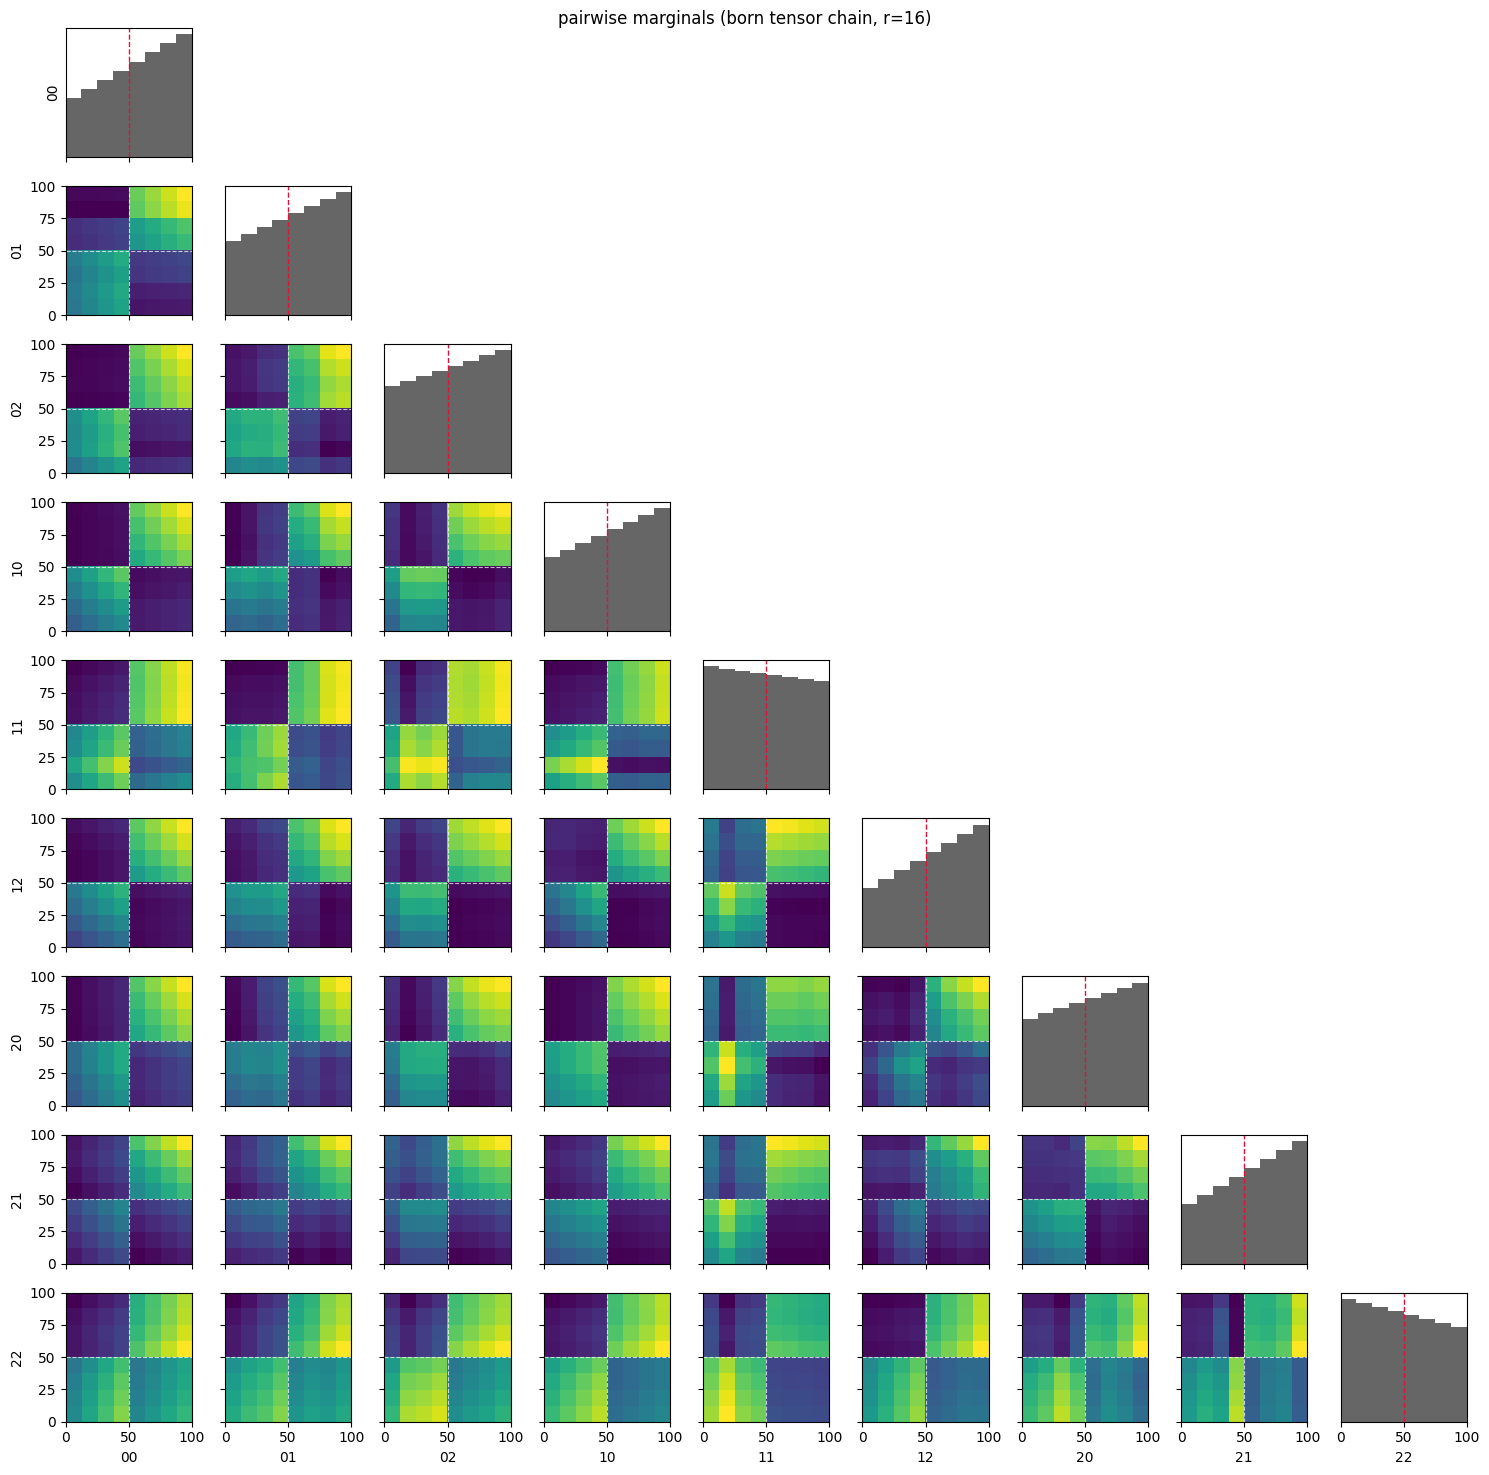

In [ ]:
_FIG = plot_pairwise(m2, p2, names=[f"{r}{c}" for r,c in NODES],
                     threshold=50, figsize=(15, 15))[0]

### Notes

* The chain uses a **row-major ordering** of the grid with bond dimension 16 —
  enough to carry the lattice's correlations across the 1-D ordering. Colliders
  whose parents are far apart in the ordering are handled by the bond dimension.
* **Uniform init** (`init="uniform"`) + a light `curvature` regularizer; no data,
  pure constraint matching. Every constraint and plotted marginal is an exact
  contraction of the network.
* General rule this illustrates: a Bayes net is reproduced by its **family
  marginals** (each node with its parents). For colliders that means triplets —
  and higher-order colliders (k parents) would need (k+1)-way marginals.